# Uber CausalML on the Hillstrom randomized email experiment

## tl;dr

The untouched holdout estimates that a Men's Email increased visit rate by
**7.35 percentage points** (95% CI: **6.13–8.57 pp**) versus No Email. All
five CausalML estimators produced an average predicted effect inside that
interval. The **T-Learner** ranked customers best by normalized Qini
(**0.0266**), while the **X-Learner** had the closest average-effect estimate
(absolute error **0.0028**).

These are reproducible RCT validation results—not evidence of an 18% ROI gain.

## Context & Methods

The [Hillstrom email challenge](https://blog.minethatdata.com/2008/03/minethatdata-e-mail-analytics-and-data.html)
contains 64,000 customers randomly assigned to Men's Email, Women's Email,
or No Email. This notebook compares CausalML S-, T-, X-, R-, and DR-Learners
on one pre-specified binary intervention: **Men's Email versus No Email**.

### Identification and validation contract

- Random assignment identifies the campaign's average causal effect without
  a no-unmeasured-confounding assumption.
- The Women's Email arm is excluded—not merged—because it is a different treatment.
- Models use only pre-treatment features; the primary outcome is a visit in
  the following two weeks.
- The preprocessor is fitted on training rows only. A stratified 30% holdout
  is never used for model fitting.
- An RCT validates average and group-level uplift. It cannot expose both
  potential outcomes for one customer, so individual PEHE is not reported.

## Data

In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from sklearn.exceptions import DataConversionWarning

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

RAW_PATH = ROOT / "data" / "raw" / "hillstrom_email_rct.csv"
PROCESSED_PATH = ROOT / "data" / "processed" / "hillstrom_mens_email_vs_control.csv"
ARTIFACT_DIR = ROOT / "artifacts"
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DataConversionWarning)
warnings.filterwarnings("ignore", message="IProgress not found.*")

In [2]:
from causal_benchmark.hillstrom import (
    experimental_effect_table,
    load_hillstrom_raw,
    load_or_create_hillstrom_contrast,
    standardized_mean_differences,
    validate_hillstrom_raw,
)
from causal_benchmark.plotting import set_plot_style

set_plot_style()
raw = load_hillstrom_raw(RAW_PATH)
quality = validate_hillstrom_raw(raw)
display(pd.Series({
    "rows": quality["rows"],
    "columns": quality["columns"],
    "missing_cells": quality["missing_cells"],
    "exact_repeated_rows_retained": quality["exact_repeated_rows"],
    "overall_visit_rate": quality["visit_rate"],
    "overall_conversion_rate": quality["conversion_rate"],
}, name="value").to_frame().style.format(precision=4))

arm_counts = pd.Series(quality["treatment_arm_counts"], name="customers")
display(arm_counts.to_frame())

,value
rows,64000.0000
columns,12.0000
missing_cells,0.0000
exact_repeated_rows_retained,6562.0000
overall_visit_rate,0.1468
overall_conversion_rate,0.0090


,customers
Womens E-Mail,21387
Mens E-Mail,21307
No E-Mail,21306


The source has no customer identifier and contains repeated combinations of
coarse attributes and outcomes. Those rows are valid randomized units, so
they are retained and assigned stable row-based IDs. The source spelling
`Surburban` is also preserved to keep the raw file unchanged.

In [3]:
effects = experimental_effect_table(raw)
display(effects.style.format({
    "treated_mean": "{:.4f}",
    "control_mean": "{:.4f}",
    "rct_difference": "{:.4f}",
}))

,campaign,outcome,treated_mean,control_mean,rct_difference
0,Mens E-Mail,visit,0.1828,0.1062,0.0766
1,Mens E-Mail,conversion,0.0125,0.0057,0.0068
2,Mens E-Mail,spend,1.4226,0.6528,0.7698
3,Womens E-Mail,visit,0.1514,0.1062,0.0452
4,Womens E-Mail,conversion,0.0088,0.0057,0.0031
5,Womens E-Mail,spend,1.0772,0.6528,0.4244


In [4]:
from causal_benchmark.hillstrom import split_hillstrom_arrays
from causal_benchmark.rct_evaluation import randomized_difference

data = load_or_create_hillstrom_contrast(RAW_PATH, PROCESSED_PATH)
arrays = split_hillstrom_arrays(data)
holdout = randomized_difference(arrays["y_test"], arrays["t_test"])
balance = standardized_mean_differences(data)

design = pd.Series({
    "binary_contrast_customers": len(data),
    "training_customers": int((data["split"] == "train").sum()),
    "holdout_customers": int((data["split"] == "test").sum()),
    "model_features_after_encoding": len(arrays["feature_names"]),
    "maximum_absolute_SMD": balance["abs_smd"].max(),
    "holdout_rct_visit_uplift": holdout["estimate"],
    "holdout_ci_lower": holdout["ci_lower"],
    "holdout_ci_upper": holdout["ci_upper"],
}, name="value")
display(design.to_frame().style.format(precision=4))
display(balance.head(11).style.format({"smd": "{:.4f}", "abs_smd": "{:.4f}"}))

,value
binary_contrast_customers,42613.0000
training_customers,29829.0000
holdout_customers,12784.0000
model_features_after_encoding,11.0000
maximum_absolute_SMD,0.0137
holdout_rct_visit_uplift,0.0735
holdout_ci_lower,0.0613
holdout_ci_upper,0.0857


,feature,smd,abs_smd
5,zip_code_Rural,0.0137,0.0137
6,zip_code_Surburban,-0.0117,0.0117
10,channel_Web,0.0110,0.0110
9,channel_Phone,-0.0083,0.0083
1,history,0.0076,0.0076
3,womens,0.0076,0.0076
0,recency,0.0068,0.0068
2,mens,-0.0046,0.0046
8,channel_Multichannel,-0.0042,0.0042
7,zip_code_Urban,0.0020,0.0020


Preprocessing passes through `recency`, `history`, `mens`, `womens`, and
`newbie`, and one-hot encodes `zip_code` and `channel`. `history_segment`
is omitted because it deterministically bins `history`. Treatment, campaign
label, customer ID, outcomes, and split are never model features.

## Results

### 1. Fit five CausalML estimators

In [5]:
from causal_benchmark.causalml_runner import run_causalml_rct_benchmark

result = run_causalml_rct_benchmark(data, artifact_dir=ARTIFACT_DIR)
metric_columns = [
    "model", "predicted_ate", "ate_abs_error", "ate_within_rct_95ci",
    "qini_score", "auuc_score", "calibration_rmse",
    "top_30pct_rct_uplift", "fit_seconds",
]
display(result.metrics[metric_columns].style.format(precision=4))

,model,predicted_ate,ate_abs_error,ate_within_rct_95ci,qini_score,auuc_score,calibration_rmse,top_30pct_rct_uplift,fit_seconds
0,T-Learner,0.0777,0.0041,True,0.0266,0.5251,0.0455,0.0949,2.2290
1,S-Learner,0.0772,0.0037,True,0.0173,0.5150,0.0408,0.0907,2.5186
2,X-Learner,0.0763,0.0028,True,0.0100,0.5056,0.0304,0.0744,4.6217
3,R-Learner,0.0772,0.0037,True,0.0073,0.5046,0.0342,0.0719,6.5514
4,DR-Learner,0.0777,0.0041,True,-0.0254,0.4706,0.0403,0.0614,5.1619


### 2. Compare targeting rank with an RCT-based Qini score

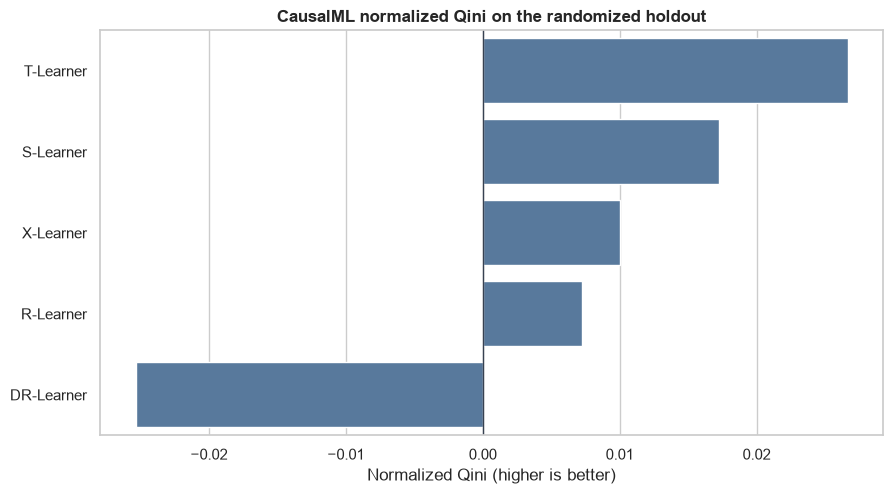

In [6]:
from causal_benchmark.plotting import plot_rct_metric

plot_rct_metric(
    result.metrics,
    "qini_score",
    title="CausalML normalized Qini on the randomized holdout",
    x_label="Normalized Qini (higher is better)",
)
plt.show()

### 3. Compare model-implied ATEs with the experimental interval

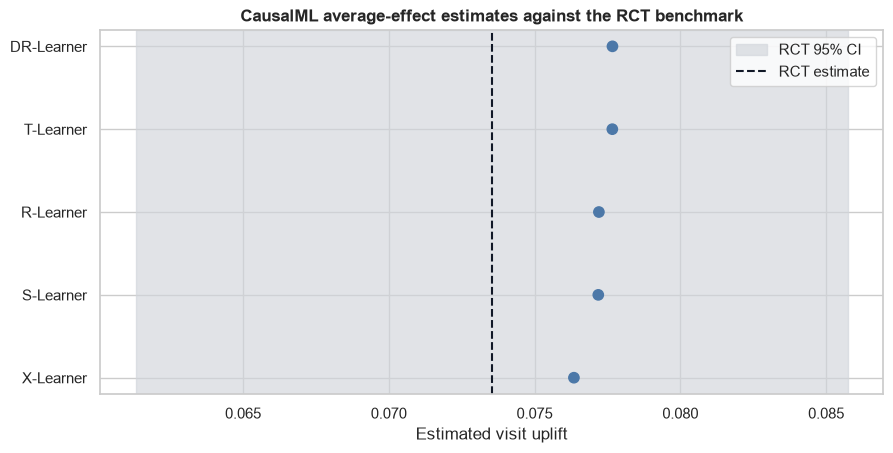

In [7]:
from causal_benchmark.plotting import plot_ate_against_rct

plot_ate_against_rct(
    result.metrics,
    title="CausalML average-effect estimates against the RCT benchmark",
)
plt.show()

### 4. Inspect uplift calibration for the best-ranked estimator

,uplift_decile,customers,treated_n,control_n,mean_predicted_cate,observed_rct_uplift,uplift_ci_lower,uplift_ci_upper
0,1,1279,659,620,0.0015,0.0657,0.0264,0.1050
1,2,1278,625,653,0.0343,0.0812,0.0434,0.1190
2,3,1278,635,643,0.0491,0.0625,0.0270,0.0980
3,4,1279,624,655,0.0598,0.0876,0.0510,0.1242
4,5,1278,634,644,0.0698,0.0288,-0.0094,0.0671
5,6,1278,676,602,0.0795,0.0566,0.0196,0.0936
6,7,1279,601,678,0.0902,0.0659,0.0272,0.1047
7,8,1278,617,661,0.1031,0.1098,0.0720,0.1476
8,9,1278,680,598,0.1231,0.1075,0.0666,0.1485
9,10,1279,641,638,0.1663,0.0648,0.0216,0.1080


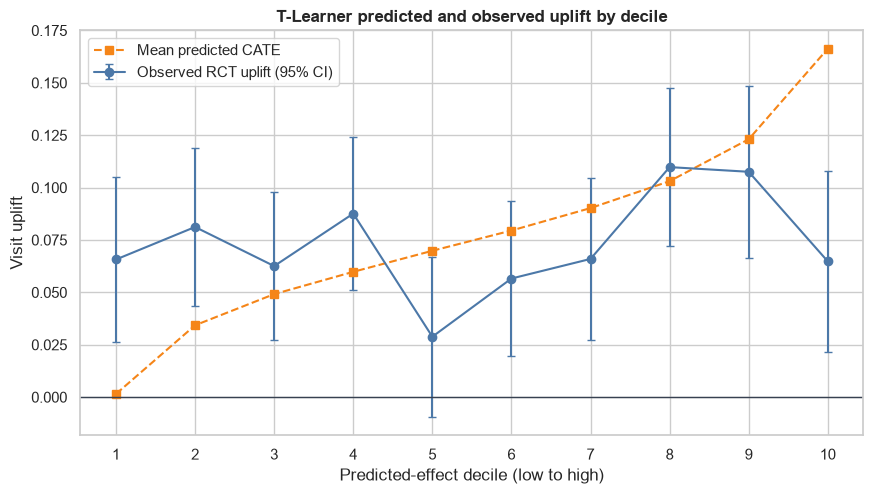

In [8]:
from causal_benchmark.plotting import plot_uplift_calibration
from causal_benchmark.rct_evaluation import uplift_calibration_table

best_model = result.metrics.sort_values("qini_score", ascending=False).iloc[0]["model"]
calibration = uplift_calibration_table(
    result.predictions["outcome"],
    result.predictions["treatment"],
    result.predictions[best_model],
)
display(calibration.style.format(precision=4))
plot_uplift_calibration(
    calibration,
    title=f"{best_model} predicted and observed uplift by decile",
)
plt.show()

### 5. Express policy performance in observed visits—not dollars

In [9]:
policy_columns = [
    "model", "policy_email_rate", "policy_incremental_visits_per_1000",
    "incremental_visits_per_1000_emailed", "top_30pct_rct_uplift",
]
display(result.metrics[policy_columns].sort_values(
    "policy_incremental_visits_per_1000", ascending=False
).style.format(precision=3))

,model,policy_email_rate,policy_incremental_visits_per_1000,incremental_visits_per_1000_emailed,top_30pct_rct_uplift
2,X-Learner,0.994,72.434,72.867,0.074
4,DR-Learner,0.994,72.121,72.581,0.061
1,S-Learner,0.976,71.965,73.753,0.091
0,T-Learner,0.964,71.339,74.032,0.095
3,R-Learner,0.984,70.557,71.701,0.072


## Takeaways

In [10]:
qini_winner = result.metrics.sort_values("qini_score", ascending=False).iloc[0]
ate_winner = result.metrics.sort_values("ate_abs_error").iloc[0]
inside = int(result.metrics["ate_within_rct_95ci"].sum())
print(
    f"Best CausalML ranking: {qini_winner['model']} "
    f"(Qini={qini_winner['qini_score']:.4f})."
)
print(
    f"Closest model-implied ATE: {ate_winner['model']} "
    f"(absolute error={ate_winner['ate_abs_error']:.4f})."
)
print(f"ATE estimates inside the RCT 95% CI: {inside}/{len(result.metrics)}.")

Best CausalML ranking: T-Learner (Qini=0.0266).
Closest model-implied ATE: X-Learner (absolute error=0.0028).
ATE estimates inside the RCT 95% CI: 5/5.


The campaign has broad positive lift, so most learned policies email nearly
everyone. The T-Learner's top 30% has higher observed uplift than the overall
holdout, but Qini is small and decile intervals are wide. This supports a
cautious targeting result—not a claim that individualized causal effects are known.